<a href="https://colab.research.google.com/github/aghyaraga-hub/Radyandra-Tugas-Pertemuan-4/blob/main/Tugas_Akhir_Radyandra_Prasya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#install dependencies

!pip install -q lightgbm shap


In [6]:
#load dataset + deteksi otomatis kolom target

import pandas as pd
import numpy as np

# Load dataset
url = "https://raw.githubusercontent.com/aghyaraga-hub/Radyandra-Tugas-Pertemuan-4/main/Supplement_Sales_Weekly_Expanded.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Bersihkan nama kolom
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nColumns setelah normalisasi:")
print(df.columns.tolist())

# Deteksi otomatis kolom target
target_keywords = ["unit", "sold", "sales", "qty", "quantity"]

target_candidates = [c for c in df.columns if any(k in c for k in target_keywords)]
print("\nKandidat kolom target:", target_candidates)

if len(target_candidates) == 0:
    raise Exception("Tidak menemukan kolom yang berhubungan dengan penjualan (units sold).")

TARGET = target_candidates[0]
print("\nTarget terdeteksi otomatis:", TARGET)

# Standardisasi: rename ke units_sold
df = df.rename(columns={TARGET: "units_sold"})
TARGET = "units_sold"

print("\nKolom target final:", TARGET)
df.head()


Shape: (4384, 10)
Columns: ['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue', 'Discount', 'Units Returned', 'Location', 'Platform']

Columns setelah normalisasi:
['date', 'product_name', 'category', 'units_sold', 'price', 'revenue', 'discount', 'units_returned', 'location', 'platform']

Kandidat kolom target: ['units_sold', 'units_returned']

Target terdeteksi otomatis: units_sold

Kolom target final: units_sold


,date,product_name,category,units_sold,price,revenue,discount,units_returned,location,platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [8]:
# ====== Replace the previous feature-selection cell with this fixed version ======
import numpy as np

# Pastikan df sudah di-load dan kolom sudah dinormalisasi (lower + underscore)
# Jika belum, lakukan:
# df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Columns available (sample):", df.columns.tolist()[:50])

# Fitur yang kamu minta (sesuaikan naming yang sudah dinormalisasi)
feature_cols = [
    "discount",         # numeric
    "unit_returned",    # numeric (kalau nama beda, akan ditangani)
    "revenue",          # numeric
    "category",         # categorical
    "product_name",     # categorical
    "location",         # categorical
    "platform"          # categorical
]

# Pisahkan tipe (numeric vs categorical)
numeric_features = ["discount", "unit_returned", "revenue"]
categorical_features = ["category", "product_name", "location", "platform"]

# Cek kolom yang hilang
missing = [c for c in feature_cols if c not in df.columns]
print("Kolom yang hilang sebelum perbaikan:", missing)

# Auto-fix: tambahkan kolom yang hilang
for c in missing:
    if c in numeric_features:
        # Jika numeric tidak ada, buat kolom bernilai 0 (atau np.nan jika ingin diimputasi nanti)
        print(f"-> Menambahkan kolom numeric '{c}' dengan nilai 0 (default).")
        df[c] = 0.0
    elif c in categorical_features:
        # Jika categorical tidak ada, isi dengan 'missing'
        print(f"-> Menambahkan kolom categorical '{c}' dengan nilai 'missing' (default).")
        df[c] = "missing"
    else:
        # fallback: treat as categorical
        print(f"-> Menambahkan kolom '{c}' (unknown type) sebagai 'missing'.")
        df[c] = "missing"

# Pastikan target units_sold ada (sebelumnya sudah distandardisasi pada sel debug)
if "units_sold" not in df.columns:
    # coba cari kandidat target lagi dengan kata kunci
    candidates = [c for c in df.columns if any(k in c for k in ["unit","sold","sales","qty","quantity"])]
    print("Mencari kandidat target lagi:", candidates)
    if len(candidates)>0:
        chosen = candidates[0]
        print("Meng-rename", chosen, "-> units_sold")
        df = df.rename(columns={chosen: "units_sold"})
    else:
        raise Exception("Target 'units_sold' tidak ditemukan. Pastikan dataset berisi kolom penjualan.")

# Buat df_model hanya dari fitur yg kita perlukan + target
df_model = df[feature_cols + ["units_sold"]].copy()

# Jika ada baris NaN di target, buang
df_model = df_model[df_model["units_sold"].notna()].reset_index(drop=True)

print("df_model shape:", df_model.shape)
display(df_model.head())


Columns available (sample): ['date', 'product_name', 'category', 'units_sold', 'price', 'revenue', 'discount', 'units_returned', 'location', 'platform']
Kolom yang hilang sebelum perbaikan: ['unit_returned']
-> Menambahkan kolom numeric 'unit_returned' dengan nilai 0 (default).
df_model shape: (4384, 8)


,discount,unit_returned,revenue,category,product_name,location,platform,units_sold
0,0.03,0.0,4573.14,Protein,Whey Protein,Canada,Walmart,143
1,0.04,0.0,5908.89,Vitamin,Vitamin C,UK,Amazon,139
2,0.25,0.0,2078.51,Omega,Fish Oil,Canada,Amazon,161
3,0.08,0.0,2249.80,Vitamin,Multivitamin,Canada,Walmart,140
4,0.25,0.0,5568.79,Performance,Pre-Workout,Canada,iHerb,157


In [9]:
#Preprocessing + Train-test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ["discount", "unit_returned", "revenue"]
categorical_features = ["category", "product_name", "location", "platform"]

X = df_model[feature_cols]
y = df_model["units_sold"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
#Model LightGBM

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

# Preprocessing pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = lgb.LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

pipeline = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", sqrt(mean_squared_error(y_test, pred)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 345
[LightGBM] [Info] Number of data points in the train set: 3507, number of used features: 34
[LightGBM] [Info] Start training from score 150.367836
MAE : 10.249164588455123
RMSE: 12.95398284286472


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [12]:
#Feature Importance

ohe = pipeline.named_steps["prep"].named_transformers_["cat"]["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_names)
importances = pipeline.named_steps["model"].feature_importances_

fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi.sort_values("importance", ascending=False).head(20)

,feature,importance
2,revenue,8504
0,discount,4298
29,location_Canada,606
30,location_UK,516
32,platform_Amazon,508
33,platform_Walmart,435
34,platform_iHerb,400
31,location_USA,367
12,category_Vitamin,208
7,category_Mineral,183


sample.shape = (500, 35)
shap_values.shape = (500, 35)


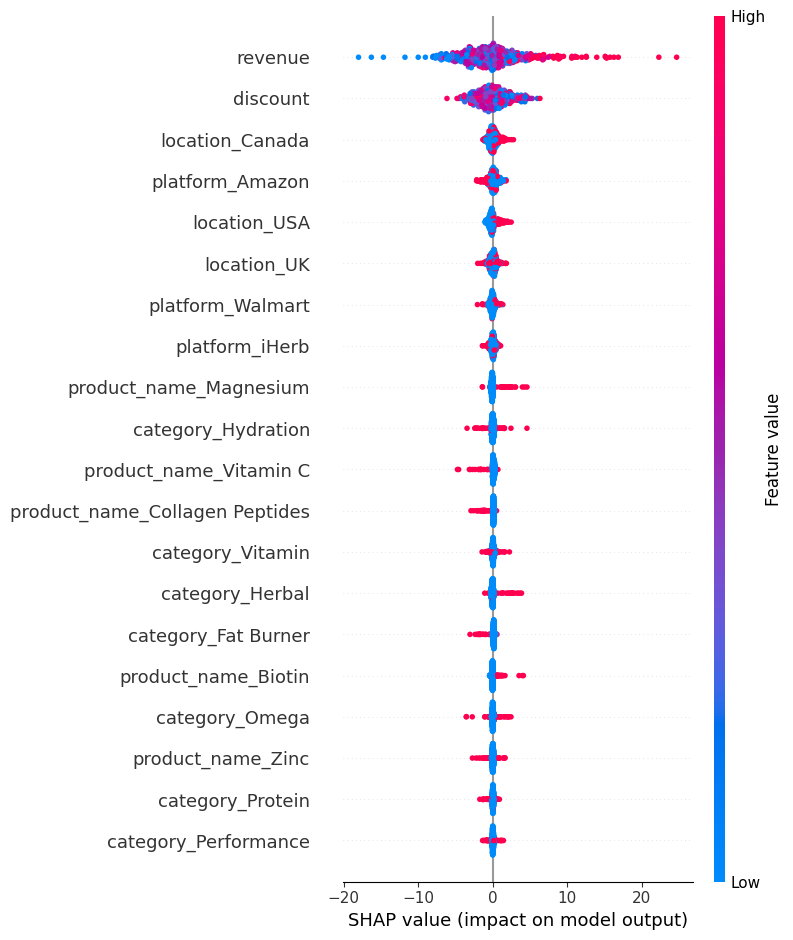

In [17]:
# ======== Perbaikan SHAP plotting (paste ganti bagian SHAP di notebook) ========
import numpy as np
import shap

# Ambil model dan preprocessor dari pipeline
model = pipeline.named_steps["model"]
preproc = pipeline.named_steps["prep"]

# Siapkan sample (tidak terlalu besar agar cepat)
Xsample = X_train.iloc[:500]  # gunakan dataframe asli sebelum transform
# Transform menggunakan preprocessor agar fitur sama urutannya
sample_transformed = preproc.transform(Xsample)

# Jika hasil transform sparse matrix -> convert to dense 2D array
try:
    # sparse matrix has .toarray() or .A
    if hasattr(sample_transformed, "toarray"):
        sample = sample_transformed.toarray()
    else:
        sample = np.asarray(sample_transformed)
except Exception as e:
    # fallback
    sample = np.asarray(sample_transformed)

# Buat explainer dan hit shap values
explainer = shap.TreeExplainer(model)

# shap_values kadang mengembalikan list (multiclass) atau array 3D
raw_shap_values = explainer.shap_values(sample)

# Normalisasi shap_values jadi array 2D (n_samples, n_features)
if isinstance(raw_shap_values, list):
    # jika list panjang 1, ambil elemen pertama
    if len(raw_shap_values) == 1:
        shap_values = raw_shap_values[0]
    else:
        # multi-output / multiclass: pilih index output yang relevan (mis idx 0)
        # Atau kamu bisa visualisasikan per-class: di sini kita ambil elemen pertama
        shap_values = raw_shap_values[0]
elif hasattr(raw_shap_values, "ndim") and raw_shap_values.ndim == 3:
    # bentuk (n_outputs, n_samples, n_features) -> ambil output pertama
    shap_values = raw_shap_values[0]
else:
    shap_values = raw_shap_values

# Pastikan shap_values sekarang 2D dan cocok dengan sample
print("sample.shape =", sample.shape)
print("shap_values.shape =", getattr(shap_values, "shape", None))

# Jika masih 3D, coba squeeze (hati-hati jika memang multi-output)
if hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_values = np.squeeze(shap_values, axis=0)
    print("After squeeze shap_values.shape =", shap_values.shape)

# Recover feature names from preprocessing (numeric + onehot)
# Jika kamu telah membuat all_feature_names sebelumnya — pakai itu. Jika belum:
try:
    # jika OneHotEncoder dipakai, get_feature_names_out tersedia
    cat_transformer = preproc.named_transformers_["cat"]
    ohe = cat_transformer.named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(categorical_features))
except Exception:
    # fallback: coba menebak jumlah fitur
    cat_names = []
try:
    feature_names = numeric_features + cat_names
except:
    # fallback generic names
    feature_names = [f"f_{i}" for i in range(sample.shape[1])]

# Terakhir tampilkan summary plot
shap.summary_plot(shap_values, sample, feature_names=feature_names)

In [14]:
#Time-series Forecasting

# Cari kolom tanggal otomatis
date_cols = [c for c in df.columns if "date" in c or "week" in c or "time" in c]

print("Kandidat kolom tanggal:", date_cols)

if len(date_cols) == 0:
    raise Exception("Dataset tidak memiliki kolom tanggal.")

DATE_COL = date_cols[0]
print("Menggunakan kolom tanggal:", DATE_COL)

# Convert date
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df_ts = df[[DATE_COL, "units_sold"]].dropna().sort_values(DATE_COL)

df_ts = df_ts.set_index(DATE_COL).resample("W").sum()

df_ts.head()

Kandidat kolom tanggal: ['date']
Menggunakan kolom tanggal: date


,units_sold
date,
2020-01-12,2406
2020-01-19,2374
2020-01-26,2370
2020-02-02,2397
2020-02-09,2384


In [15]:
#Forecasting menggunakan LightGBM

ts = df_ts.copy()

# Buat lag features
for lag in [1, 2, 3, 4, 8, 12]:
    ts[f"lag_{lag}"] = ts["units_sold"].shift(lag)

ts = ts.dropna()

X_ts = ts.drop(columns=["units_sold"])
y_ts = ts["units_sold"]

train_size = int(len(ts)*0.8)
X_train_ts, X_test_ts = X_ts.iloc[:train_size], X_ts.iloc[train_size:]
y_train_ts, y_test_ts = y_ts.iloc[:train_size], y_ts.iloc[train_size:]

model_ts = lgb.LGBMRegressor()
model_ts.fit(X_train_ts, y_train_ts)

pred_ts = model_ts.predict(X_test_ts)

print("MAE forecasting:", mean_absolute_error(y_test_ts, pred_ts))
print("RMSE forecasting:", sqrt(mean_squared_error(y_test_ts, pred_ts)))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 209, number of used features: 6
[LightGBM] [Info] Start training from score 2401.885167
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

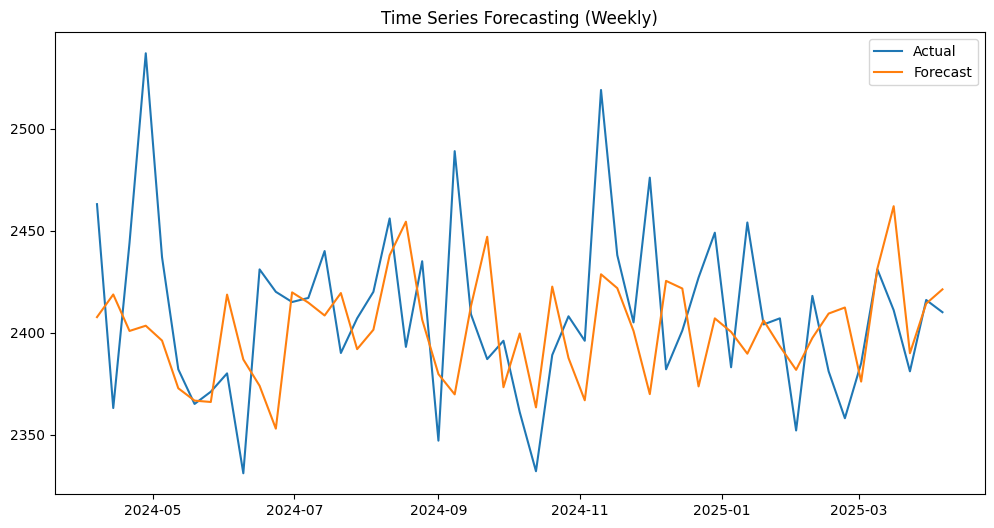

In [16]:
#Plot Forecast vs Actual

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_ts.index, y_test_ts, label="Actual")
plt.plot(y_test_ts.index, pred_ts, label="Forecast")
plt.legend()
plt.title("Time Series Forecasting (Weekly)")
plt.show()